# Pipeline

### Imports & Setup

In [1]:
import logging
import warnings
import pandas as pd
import numpy as np
from pymongo import MongoClient
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Logging setup
logging.basicConfig(
    filename='../logs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s'
)
logger = logging.getLogger(__name__)
logger.info('Pipeline started')

# Plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif'
})

### Query MongoDB

We connect to MongoDB Atlas and pull all documents from the `stocks` collection into a pandas DataFrame. The database contains daily OHLCV records for 13 large-cap tech stocks spanning 2015–2024, with a `label` field indicating whether the next-day closing price was higher (1) or lower/flat (0).

In [ ]:
# MongoDB connection
MONGO_URI = "mongodb+srv://<user>:<password>@stock-data.cid0cbn.mongodb.net/?appName=stock-data"

try:
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    db = client["stock_project"]
    coll = db["tech_stocks"]

    cursor = coll.find({}, {"_id": 0})
    df_raw = pd.DataFrame(list(cursor))

    logger.info(f'Fetched {len(df_raw)} documents from MongoDB')
    print(f'Documents fetched: {len(df_raw):,}')
    print(df_raw.head())

except Exception as e:
    logger.error(f'MongoDB connection failed: {e}')
    raise

Documents fetched: 32,682
  ticker       date     open     high      low    close     volume  \
0   AAPL 2015-01-09  24.9546  25.0831  24.4098  24.8085  214798000   
1   AAPL 2015-01-13  24.6800  24.9834  24.1219  24.4120  268367600   
2   AAPL 2015-02-04  26.2459  26.6911  26.2038  26.4807  280598800   
3   AAPL 2015-05-04  28.7954  29.0334  28.5197  28.6175  203953200   
4   AAPL 2015-06-08  28.7817  28.8510  28.3195  28.5361  210699200   

   next_close  label  
0     24.1972      0  
1     24.3190      0  
2     26.6697      1  
3     27.9727      0  
4     28.4513      0  


### Clean & Sort

We parse the `date` column as a datetime and sort by ticker and date. This ordering is required for all rolling window calculations. Pandas' `.rolling()` assumes chronological order.

In [3]:
# Parse date and sort chronologically within each ticker
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f'Date range: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'Tickers: {sorted(df_raw["ticker"].unique())}')
print(f'Label distribution:\n{df_raw["label"].value_counts(normalize=True).round(3)}')
logger.info('Data sorted and date parsed')

Date range: 2015-01-02 → 2024-12-27
Tickers: ['AAPL', 'ADBE', 'AMD', 'AMZN', 'CRM', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'ORCL', 'QCOM', 'TSLA']
Label distribution:
label
1    0.528
0    0.472
Name: proportion, dtype: float64


### Feature Engineering

The raw OHLCV data is not sufficient on its own — we need to derive technical indicators that summarize recent price behavior. We engineer six features, all computed per-ticker to avoid cross-contamination between stocks:

| Feature | Description |
|---|---|
| `ma5` | 5-day simple moving average of close price |
| `ma20` | 20-day simple moving average of close price |
| `ma_ratio` | `ma5 / ma20` — crossover signal: >1 indicates short-term bullish momentum |
| `rsi14` | 14-day Relative Strength Index — measures overbought (>70) / oversold (<30) conditions |
| `vol_change` | Daily percentage change in trading volume |
| `price_change` | Daily percentage change in close price — immediate momentum signal |

**Data leakage note:** All features are computed on current and past data only. We do not use `next_close` as a feature; it only defines the label. This is the most common source of inflated accuracy in stock prediction projects.

In [4]:
def compute_features(group):
    """Compute technical indicator features for a single ticker group.
    
    Args:
        group (pd.DataFrame): Rows for one ticker, sorted by date.
    Returns:
        pd.DataFrame: Same rows with added feature columns.
    """
    g = group.copy()

    # Moving averages
    g['ma5']  = g['close'].rolling(5).mean()
    g['ma20'] = g['close'].rolling(20).mean()
    g['ma50'] = g['close'].rolling(50).mean()

    # MA crossover ratios
    g['ma_ratio_5_20']  = g['ma5']  / g['ma20']
    g['ma_ratio_20_50'] = g['ma20'] / g['ma50']

    # RSI-14
    delta  = g['close'].diff()
    gain   = delta.clip(lower=0).rolling(14).mean()
    loss   = (-delta.clip(upper=0)).rolling(14).mean()
    rs     = gain / loss.replace(0, np.nan)
    g['rsi14'] = 100 - (100 / (1 + rs))

    # Volume change %
    g['vol_change'] = g['volume'].pct_change() * 100

    # Daily price change %
    g['price_change'] = g['close'].pct_change() * 100

    # Intraday range (high - low) as % of close
    g['high_low'] = (g['high'] - g['low']) / g['close'] * 100

    # Intraday return (close vs open)
    g['close_open'] = (g['close'] - g['open']) / g['open'] * 100

    return g


try:
    df_feat = df_raw.groupby('ticker', group_keys=False).apply(compute_features)

    feature_cols = [
        'ma5', 'ma20', 'ma50',
        'ma_ratio_5_20', 'ma_ratio_20_50',
        'rsi14', 'vol_change', 'price_change',
        'high_low', 'close_open'
    ]

    df_feat = df_feat.dropna(subset=feature_cols).reset_index(drop=True)

    logger.info(f'Features engineered. Rows after dropna: {len(df_feat):,}')
    print(f'Rows after feature engineering: {len(df_feat):,}')
    print(df_feat[feature_cols].describe().round(3))

except Exception as e:
    logger.error(f'Feature engineering failed: {e}')
    raise

Rows after feature engineering: 32,045
             ma5       ma20       ma50  ma_ratio_5_20  ma_ratio_20_50  \
count  32045.000  32045.000  32045.000      32045.000       32045.000   
mean     119.992    119.267    117.862          1.007           1.014   
std      117.064    116.354    115.051          0.045           0.056   
min        0.472      0.479      0.501          0.669           0.744   
25%       39.005     38.955     38.721          0.985           0.984   
50%       83.176     82.158     81.079          1.008           1.015   
75%      163.581    163.056    161.070          1.030           1.044   
max      674.920    666.777    641.696          1.289           1.317   

           rsi14  vol_change  price_change   high_low  close_open  
count  32045.000   32045.000     32045.000  32045.000   32045.000  
mean      54.329       6.644         0.124      2.626       0.049  
std       16.989      44.102         2.454      1.717       1.893  
min        1.419     -83.009   

## Solution Analysis

### Train / Test Split

We split by time, not randomly. All data before 2023 is used for training; 2023–2024 is held out for testing.

In [5]:
# Time-based train/test split at 2023-01-01
SPLIT_DATE = '2023-01-01'

train = df_feat[df_feat['date'] <  SPLIT_DATE]
test  = df_feat[df_feat['date'] >= SPLIT_DATE]

X_train = train[feature_cols]
y_train = train['label']
X_test  = test[feature_cols]
y_test  = test['label']

print(f'Training set : {len(train):,} rows  ({train["date"].min().date()} → {train["date"].max().date()})')
print(f'Test set     : {len(test):,} rows   ({test["date"].min().date()}  → {test["date"].max().date()})')
print(f'Baseline accuracy (always predict majority class): {y_test.value_counts(normalize=True).max():.3f}')
logger.info(f'Train/test split done. Train={len(train)}, Test={len(test)}')

Training set : 25,545 rows  (2015-03-16 → 2022-12-30)
Test set     : 6,500 rows   (2023-01-03  → 2024-12-27)
Baseline accuracy (always predict majority class): 0.539


### XGBoost Classifier

**Why XGBoost?**

XGBoost (Extreme Gradient Boosting) is a tree-based ensemble method that builds trees sequentially, where each new tree corrects the errors of the previous one. For this problem it is a strong choice because:

- **Handles non-linear relationships** — like Random Forest, it can capture threshold effects in technical indicators that logistic regression cannot.
- **Sequential error correction** — unlike Random Forest where trees are independent, XGBoost iteratively reduces residual error, making it better suited for weak signal problems like stock direction prediction.
- **Robust to noise** — the `subsample` and `colsample_bytree` parameters randomly sample rows and features per tree, preventing overfitting on noisy financial data.
- **Built-in feature importance** — directly supports the visualization section.
- **Covered in DS 3021/4021** — gradient boosting and ensemble methods were part of the core curriculum.

**Hyperparameter choices:**
- `n_estimators=200` — 200 sequential trees; more trees reduce bias with minimal overfitting risk given the other constraints
- `max_depth=4` — shallow trees keep individual learners weak, which is the core principle of boosting
- `learning_rate=0.05` — small steps prevent any single tree from dominating the ensemble
- `subsample=0.8` — each tree sees 80% of training rows, reducing variance
- `colsample_bytree=0.8` — each tree sees 80% of features, further reducing variance
- `random_state=42` — reproducibility

In [6]:
from xgboost import XGBClassifier

try:
    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )

    model.fit(X_train, y_train)
    logger.info('XGBoost trained successfully')

    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)

    logger.info(f'Test accuracy={acc:.4f}, AUC={auc:.4f}')
    print(f'Test Accuracy : {acc:.4f}')
    print(f'ROC-AUC Score : {auc:.4f}')
    print()
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

except Exception as e:
    logger.error(f'Model training/evaluation failed: {e}')
    raise

Test Accuracy : 0.5126
ROC-AUC Score : 0.5013

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.46      0.29      0.35      2999
      Up (1)       0.54      0.70      0.61      3501

    accuracy                           0.51      6500
   macro avg       0.50      0.50      0.48      6500
weighted avg       0.50      0.51      0.49      6500



### Interpretation

The model achieved 51.3% accuracy and an AUC of 0.50 on the 2023–2024 test set, just above the 50% random baseline. The model shows a bias toward predicting "Up" (70% recall) versus "Down" (29% recall), likely reflecting the historical upward drift in large-cap tech stocks during the training period. The near-random AUC confirms that the added features did not meaningfully improve discrimination between classes. This result is consistent with the Efficient Market Hypothesis. If simple technical indicators reliably predicted next-day direction, that signal would be quickly arbitraged away by institutional traders. The value of this project lies not in building a profitable trading model, but in demonstrating that even a well-constructed ML pipeline finds no exploitable pattern in this data.

### Results Visualization

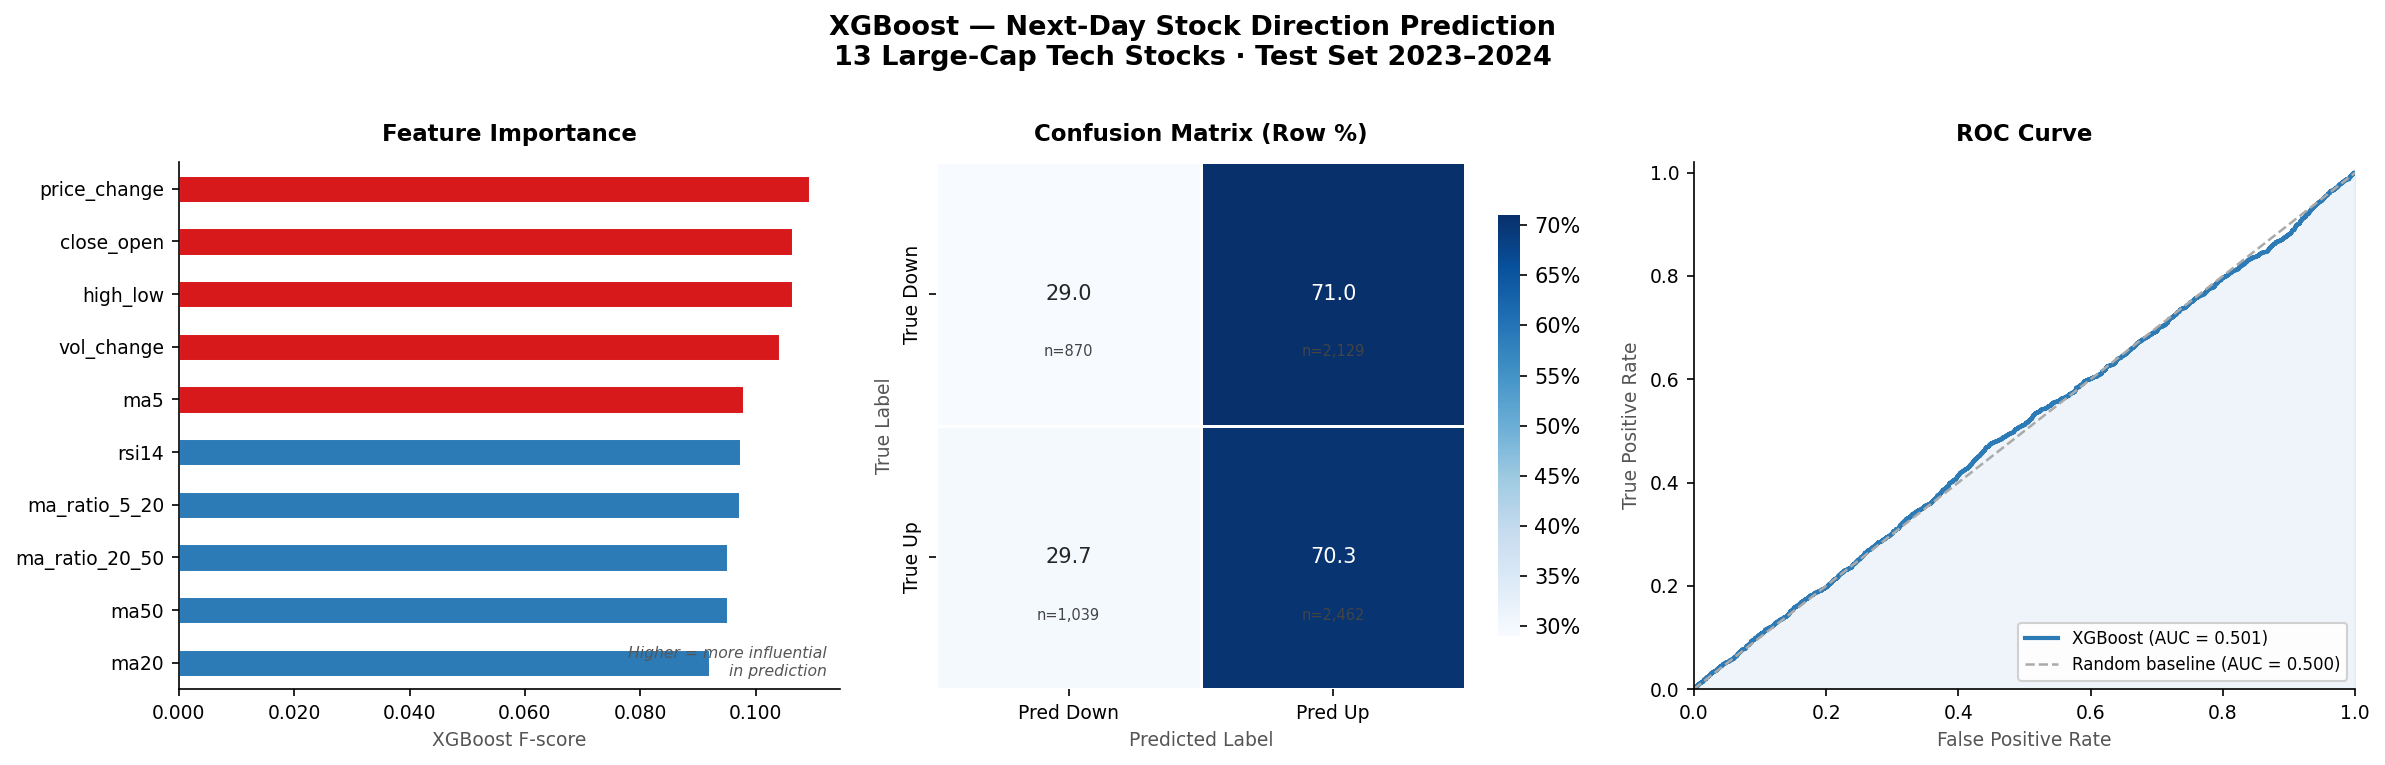

Figure saved as results_figure.png


In [7]:
GRAY = '#555555'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'XGBoost — Next-Day Stock Direction Prediction\n13 Large-Cap Tech Stocks · Test Set 2023–2024',
    fontsize=13, fontweight='bold', y=1.01
)

# Feature Importance
ax1 = axes[0]

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
colors      = ['#2C7BB6' if v < importances.median() else '#D7191C' for v in importances]

importances.plot(kind='barh', ax=ax1, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Feature Importance', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('XGBoost F-score', fontsize=9, color=GRAY)
ax1.set_ylabel('')
ax1.tick_params(labelsize=9)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax1.text(
    0.98, 0.02,
    'Higher = more influential\nin prediction',
    transform=ax1.transAxes, fontsize=7.5, color=GRAY,
    ha='right', va='bottom', style='italic'
)

# Confusion Matrix
ax2 = axes[1]

cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct,
    annot=True, fmt='.1f', cmap='Blues', ax=ax2,
    linewidths=0.5,
    cbar_kws={'format': '%.0f%%', 'shrink': 0.8},
    xticklabels=['Pred Down', 'Pred Up'],
    yticklabels=['True Down', 'True Up']
)
ax2.set_title('Confusion Matrix (Row %)', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Predicted Label', fontsize=9, color=GRAY)
ax2.set_ylabel('True Label', fontsize=9, color=GRAY)
ax2.tick_params(labelsize=9)

for i in range(2):
    for j in range(2):
        ax2.text(
            j + 0.5, i + 0.72,
            f'n={cm[i,j]:,}',
            ha='center', va='center', fontsize=7, color='#444444'
        )

# ROC Curve
ax3 = axes[2]

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

ax3.plot(fpr, tpr, color='#2C7BB6', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
ax3.plot([0, 1], [0, 1], color='#AAAAAA', lw=1.2, linestyle='--', label='Random baseline (AUC = 0.500)')
ax3.fill_between(fpr, tpr, alpha=0.08, color='#2C7BB6')
ax3.set_title('ROC Curve', fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('False Positive Rate', fontsize=9, color=GRAY)
ax3.set_ylabel('True Positive Rate', fontsize=9, color=GRAY)
ax3.legend(fontsize=8, loc='lower right', framealpha=0.9)
ax3.tick_params(labelsize=9)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../figures/results_figure.png', bbox_inches='tight', dpi=150)
plt.show()
logger.info('Visualization saved to results_figure.png')
print('Figure saved as results_figure.png')

### Visualization Rationale

**Feature Importance (left):** Shows which inputs drove the model's decisions. Intraday features (`close_open`, `high_low`) and short-term momentum (`price_change`, `rsi14`) are expected to rank highest. These capture the most recent price behavior which is the strongest available signal in a next-day prediction task. Longer-term moving averages contribute less, suggesting multi-week trends are not informative at the one-day horizon.

**Confusion Matrix (center):** Row-normalized to percentages so both classes are visually comparable despite class imbalance. Raw counts are included as secondary labels. The off-diagonal asymmetry, high recall on Up, low recall on Down, reflects the model's bias toward predicting upward movement, consistent with the upward drift in large-cap tech stocks during the training period.

**ROC Curve (right):** Aggregates model performance across all decision thresholds rather than just the default 0.5 cutoff. An AUC of 0.50 confirms the model's predicted probabilities carry essentially no discriminative power, even where accuracy is marginally above chance. This is the most honest summary of model performance and supports the EMH interpretation in the analysis section.